In [ ]:
import pandas as pd
import datetime as dt

## Raw Data

We get the date from Compustat Global provided by WRDS

In [23]:
df = pd.read_parquet('../data/raw/eu_data.parquet')

df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2212385 entries, 0 to 2212384
Data columns (total 165 columns):
 #    Column                Non-Null Count    Dtype         
---   ------                --------------    -----         
 0    id                    2212385 non-null  Float64       
 1    eom                   2212385 non-null  datetime64[ns]
 2    excntry               2212385 non-null  string        
 3    gvkey                 2212385 non-null  string        
 4    permno                0 non-null        string        
 5    size_grp              2200974 non-null  string        
 6    me                    2200974 non-null  Float64       
 7    ret_exc_lead1m        2176839 non-null  Float64       
 8    conm                  0 non-null        string        
 9    tic                   0 non-null        string        
 10   isin                  0 non-null        string        
 11   sedol                 0 non-null        string        
 12   niq_su                1004

In [24]:
df.head()

,id,eom,excntry,gvkey,permno,size_grp,me,ret_exc_lead1m,conm,tic,...,rmax5_rvol_21d,ni_be,ocf_at,ocf_at_chg1,mispricing_perf,mispricing_mgmt,qmj,qmj_prof,qmj_growth,qmj_safety
0,301552601.0,1988-12-31,AUT,015526,<NA>,small,108.216207,-0.026477,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,301552601.0,1989-01-31,AUT,015526,<NA>,small,105.974971,0.027587,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,301552601.0,1989-02-28,AUT,015526,<NA>,small,109.545962,-0.016294,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,301552601.0,1989-03-31,AUT,015526,<NA>,small,108.441669,0.059173,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,301552601.0,1989-04-30,AUT,015526,<NA>,small,115.596958,0.163644,<NA>,<NA>,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Clean data

We then do some preprocessing in the form of:
1. Adding indicator colums for characteristics with more than 5% missing data
2. Uniformizing all of the characteristics on a [-1, 1] scale
3. Handling missing characteristic data via cross-sectional median imputation
4. Winsorizing the returns on [0.00, 0.99] interval

In [25]:
df = pd.read_parquet('../data/processed/clean_data.parquet')


df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 1535544 entries, 0 to 2212383
Data columns (total 311 columns):
 #    Column                        Non-Null Count    Dtype         
---   ------                        --------------    -----         
 0    id                            1535544 non-null  Float64       
 1    eom                           1535544 non-null  datetime64[ns]
 2    excntry                       1535544 non-null  string        
 3    gvkey                         1535544 non-null  string        
 4    permno                        0 non-null        string        
 5    size_grp                      1535544 non-null  string        
 6    me                            1535544 non-null  Float64       
 7    ret_exc_lead1m                1535544 non-null  Float64       
 8    conm                          0 non-null        string        
 9    tic                           0 non-null        string        
 10   isin                          0 non-null        string   

In [26]:
df.index = df['eom']

df.head()

,id,eom,excntry,gvkey,permno,size_grp,me,ret_exc_lead1m,conm,tic,...,rmax5_21d_missing,rmax5_rvol_21d_missing,ni_be_missing,ocf_at_missing,ocf_at_chg1_missing,mispricing_mgmt_missing,qmj_missing,qmj_prof_missing,qmj_growth_missing,qmj_safety_missing
eom,,,,,,,,,,,,,,,,,,,,,
1988-12-31,301552601.0,1988-12-31,AUT,015526,<NA>,small,108.216207,-0.026477,<NA>,<NA>,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1989-01-31,301552601.0,1989-01-31,AUT,015526,<NA>,small,105.974971,0.027587,<NA>,<NA>,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1989-02-28,301552601.0,1989-02-28,AUT,015526,<NA>,small,109.545962,-0.016294,<NA>,<NA>,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1989-03-31,301552601.0,1989-03-31,AUT,015526,<NA>,small,108.441669,0.059173,<NA>,<NA>,...,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1989-04-30,301552601.0,1989-04-30,AUT,015526,<NA>,small,115.596958,0.163644,<NA>,<NA>,...,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


count    1535544.0
mean      0.004141
std       0.124394
min      -0.876422
25%      -0.053918
50%       0.000241
75%       0.056959
max       3.262562
Name: ret_exc_lead1m, dtype: Float64

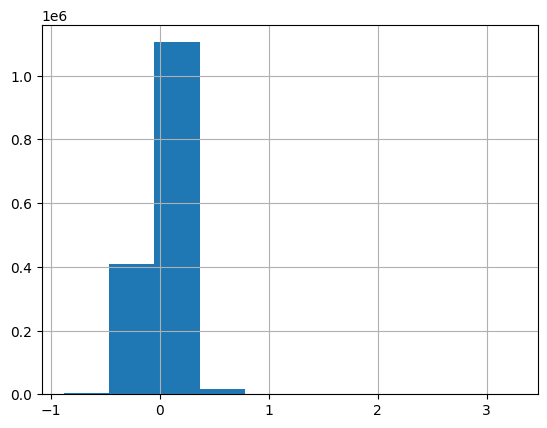

In [27]:
df['ret_exc_lead1m'].hist()

df['ret_exc_lead1m'].describe()

<Axes: xlabel='eom'>

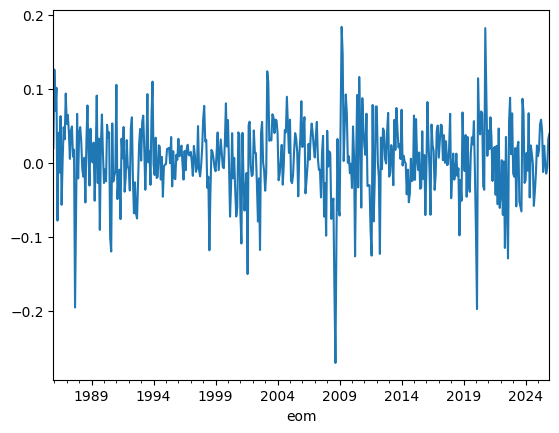

In [28]:
df.groupby(level=0)['ret_exc_lead1m'].mean().plot()

<Axes: xlabel='eom'>

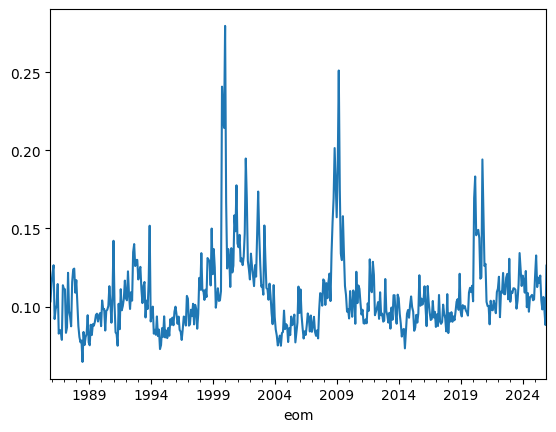

In [29]:
df.groupby(level=0)['ret_exc_lead1m'].std().plot()

The 3 large spikes in volatility and drops in mean value correstpond to the Dot-com crisis, 2008 crisis and COVID crisis. These should be taken into account when choosing a train/test split.

In [30]:
df['size_grp'].value_counts()

size_grp
micro    832763
small    372948
large    220664
mega     109169
Name: count, dtype: Int64

We have more smaller size firms. It should be noted that we excluded nano size firms during preprocessing

<Axes: >

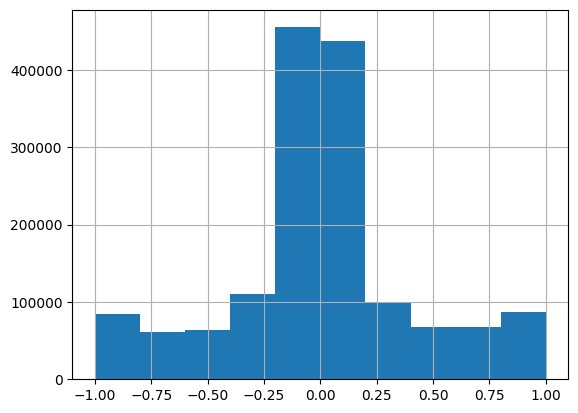

In [31]:
df['saleq_su'].hist()

<Axes: >

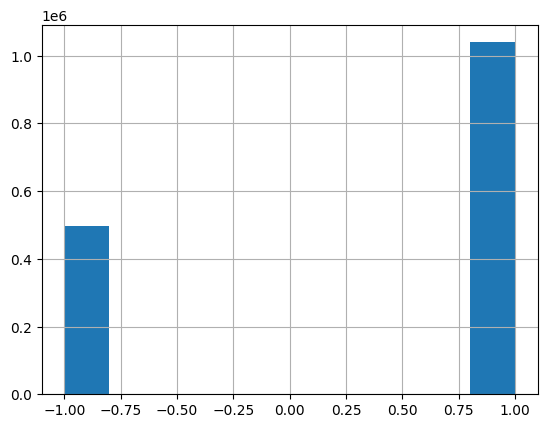

In [32]:
df['saleq_su_missing'].hist()

As you can see the features are properly uniformized

<Axes: xlabel='eom'>

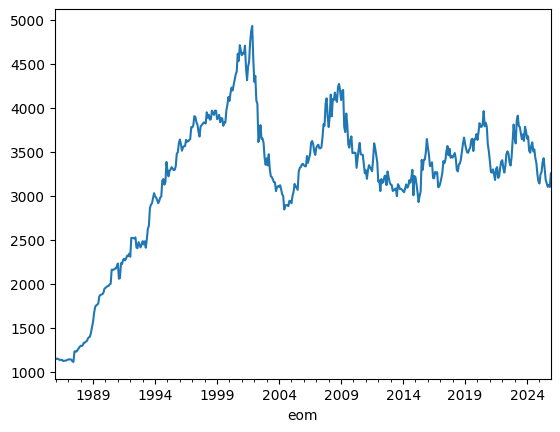

In [33]:
df.groupby(level=0)['gvkey'].nunique().plot()

Plots of both the number of the number of companies by date promt us to use a wider testing set

In [34]:
def end_of_month(date):
    month_today = date.month
    month_tommorow = (date + dt.timedelta(days=1)).month
    return month_today != month_tommorow

In [35]:
are_eom = [end_of_month(date) for date in df.index]

False in are_eom

False

After conducting a sanity check we can say for sure that the eom column of our data frame (its index) contain only end of month dates. This will be crucial for the training and testing process